# Geometría Geoespacial

In [96]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Librerias para modelo XGBoost
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBRegressor

# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

In [2]:
# Carga de los datos 
df_train = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_ZCTACoordinates.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train)
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.386350,Moderate,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403469,Moderate,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.529389,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 171737 non-null  int64         
 1   psa                     171685 non-null  object        
 2   date                    171737 non-null  datetime64[ms]
 3   hour                    171737 non-null  int32         
 4   crime_description       171737 non-null  object        
 5   time_of_day             171737 non-null  object        
 6   day_of_week             171737 non-null  object        
 7   week_of_year            171737 non-null  int64         
 8   month                   171737 non-null  object        
 9   season                  171737 non-null  object        
 10  is_holiday              171737 non-null  bool          
 11  crimeType               171737 non-null  object        
 12  ZCTA                  

## Análisis de los datos

Ahora graficamos algunas variables que componen mi base de entrenamiento para intentar identificar si podría existir correlación espacial. En este caso, nuestra variable target muestra un nivel de correlación bastante visible.

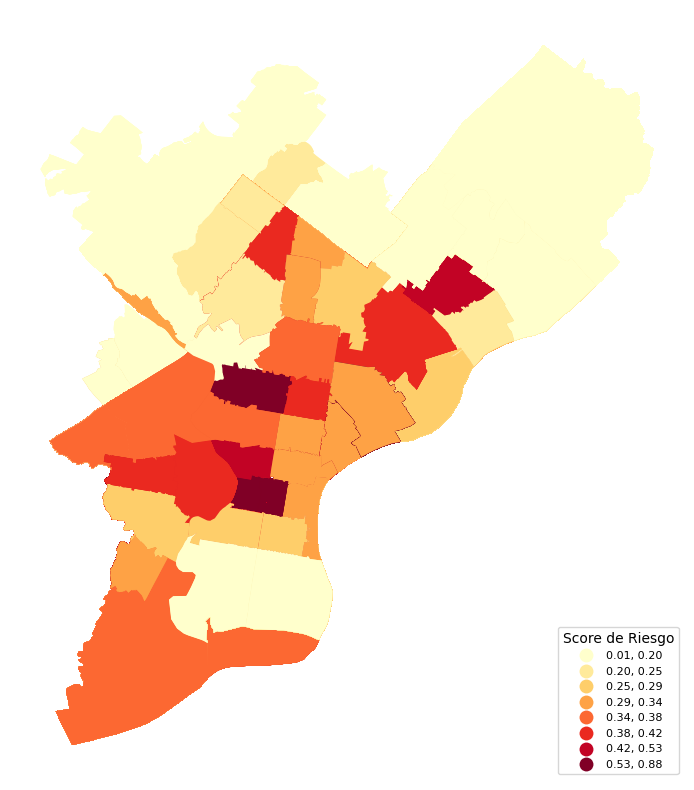

In [10]:
map=df_train.plot(column='risk_score', 
         scheme='quantiles',
         k=8, cmap='YlOrRd',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Score de Riesgo'} 
)
map.set_axis_off()    

Ahora se hace lo mismo pero para el Índice de Gini, que se encarga de cuantificar la desigualdad en los ingresos de la población, y entre más cercano a 1, mayor desigualdad. Acá notamos un patrón interesante y es que en las zonas en en donde el índice es mál alto, coinciden en su mayoría con zonas en donde se tienen niveles de score de riesgo alto. La zona central de Filadelfia es una clara evidencia de ello y entre más nos alejamos el índice tiende a disminuir, algo totalmente análogo a lo que sucede con el score.

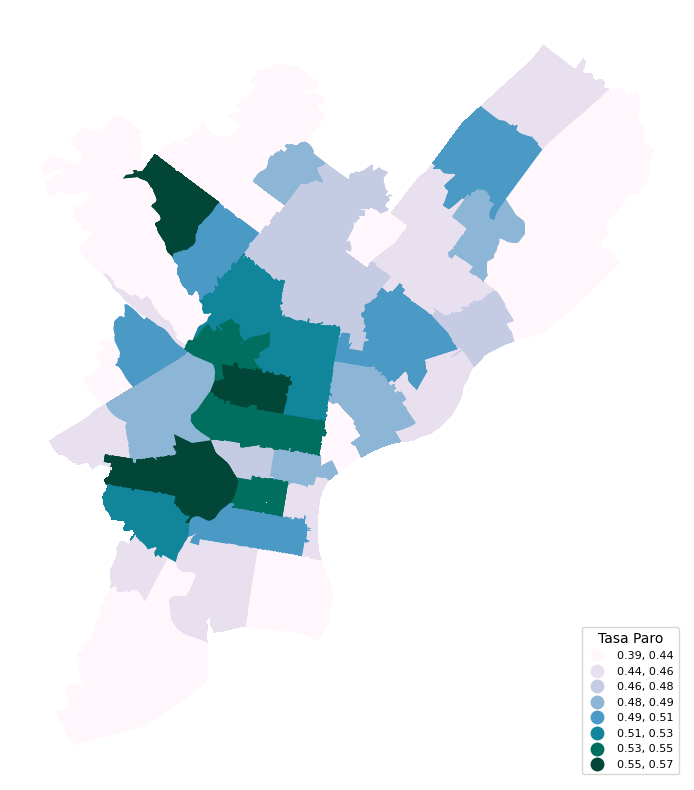

In [ ]:
map=df_train.plot(column='GiniIndex', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Índice de Gini'} 
)
map.set_axis_off() 

Con el ingreso medio más bien sucede lo contrario. Las zonas que reportan los ingresos anuales más altos tienden a estar lejos del centro de la ciudad por lo que podemos intuir una asociación negativa entre el ingreso medio y lo segura que puede llegar a ser la zona. Todos estas relaciones se estudiarán a mayor profundidad con el Índice de Correlación de Moran más adelante. 

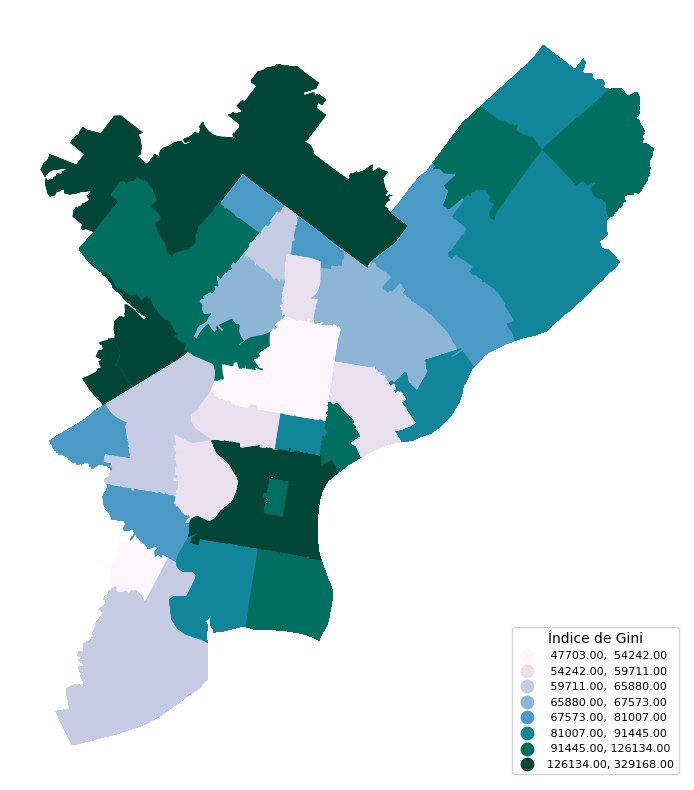

In [ ]:
map=df_train.plot(column='mean_income', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Ingreso Medio'} 
)
map.set_axis_off() 

## Se construye matriz de Contiguidad

Se procede a agrupar los datos por ZCTA para calcular un promedio del score de riesgo. Esto se hace así dado que para calcular la matriz de contigüididad solo es neceario los polígonos (coordenadas) de cada código ZCTA.  Para el resto de las variables basta tomar el primer valor (first) dado que fueron calculos que ya estaban agrupados por código ZCTA.

In [4]:
df_train.columns

Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA', 'area_mile2', 'population', 'white_race',
       'black_race', 'asian_race', 'latino_race', 'density_mile2',
       'median_income', 'mean_income', 'total_households',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry'],
      dtype='object')

In [3]:
# Se hace agrupamiento
aggregate_df_train = df_train.groupby(['ZCTA']).agg({
    'geometry': 'first',
    'area_mile2' : 'first',
    'density_mile2': 'first',
    'population': 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

,ZCTA,geometry,area_mile2,density_mile2,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,19004,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",2.725937,3913.517078,10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056757
1,19012,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",1.748582,3831.103562,6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163073
2,19027,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",3.934618,4872.138000,19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036575


Para ello se utiliza el enfoque tipo reina, es decir, se considerarán vecinos todas aquellas zonas que colinden de manera directa.

In [4]:
# Matriz de pesos por vecindad tipo Reina
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_1384\3665105975.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


Esta es la cantidad de zonas que hay:

In [8]:
print(wq.n)

55


Los vecinos de cada zona:

In [9]:
wq.neighbors

{0: [26, 4, 28, 30],
 1: [25, 2, 19, 12],
 2: [1, 49, 19, 5, 37, 25],
 3: [49, 18, 5, 17],
 4: [0, 50, 30],
 5: [49, 2, 3, 37],
 6: [29, 7, 10, 11, 45, 46],
 7: [8, 29, 45, 6],
 8: [29, 20, 38, 7, 42, 45, 30],
 9: [46, 10, 22, 47],
 10: [29, 6, 22, 9, 11, 45, 46],
 11: [10, 6],
 12: [48, 1, 19, 51, 23, 15],
 13: [52, 44, 47],
 14: [16, 51, 35, 53, 15],
 15: [16, 51, 53, 12, 14],
 16: [53, 14, 15],
 17: [27, 18, 3, 54],
 18: [49, 17, 3, 37, 43, 27],
 19: [1, 2, 23, 39, 40, 25, 12],
 20: [21, 22, 8, 29, 30, 31],
 21: [32, 20, 22, 24, 29, 31],
 22: [20, 21, 24, 9, 10, 29],
 23: [48, 33, 34, 19, 36, 39, 12],
 24: [32, 33, 21, 22],
 25: [1, 2, 19, 37, 40],
 26: [0, 27, 28],
 27: [17, 18, 54, 26, 43, 28],
 28: [0, 39, 27, 26, 43, 30, 31],
 29: [6, 7, 8, 10, 20, 21, 22, 30],
 30: [0, 4, 38, 8, 50, 20, 28, 29, 31],
 31: [32, 20, 21, 39, 28, 30],
 32: [33, 21, 39, 24, 31],
 33: [32, 36, 23, 39, 24],
 34: [48, 35, 36, 23],
 35: [48, 34, 51, 14],
 36: [33, 34, 23],
 37: [49, 2, 18, 5, 40, 25, 43]

No hay ninguna isla.

In [10]:
# No hay islas
wq.islands

[]

Cantidad de vecinos para cada zona:

In [17]:
# Cardinal del número de vecinos para cada observación
wq.cardinalities

{0: 4,
 1: 4,
 2: 6,
 3: 4,
 4: 3,
 5: 4,
 6: 6,
 7: 4,
 8: 7,
 9: 4,
 10: 7,
 11: 2,
 12: 6,
 13: 3,
 14: 5,
 15: 5,
 16: 3,
 17: 4,
 18: 6,
 19: 7,
 20: 6,
 21: 6,
 22: 6,
 23: 7,
 24: 4,
 25: 5,
 26: 3,
 27: 6,
 28: 7,
 29: 8,
 30: 9,
 31: 6,
 32: 5,
 33: 5,
 34: 4,
 35: 4,
 36: 3,
 37: 7,
 38: 4,
 39: 8,
 40: 5,
 41: 2,
 42: 6,
 43: 6,
 44: 6,
 45: 8,
 46: 6,
 47: 5,
 48: 5,
 49: 5,
 50: 3,
 51: 5,
 52: 4,
 53: 3,
 54: 2}

In [18]:
pd.Series(wq.cardinalities).describe()

count    55.000000
mean      5.054545
std       1.648997
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       9.000000
dtype: float64

<Axes: ylabel='Frequency'>

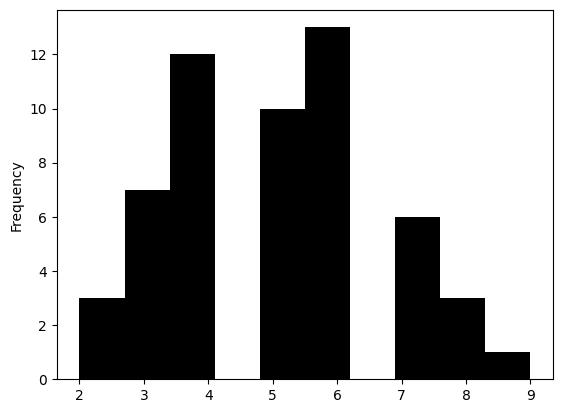

In [19]:
pd.Series(wq.cardinalities).plot.hist(color="k")

Este es un gráfico en el que se muestra, mediante conexiones, las vecindades de cada zona.

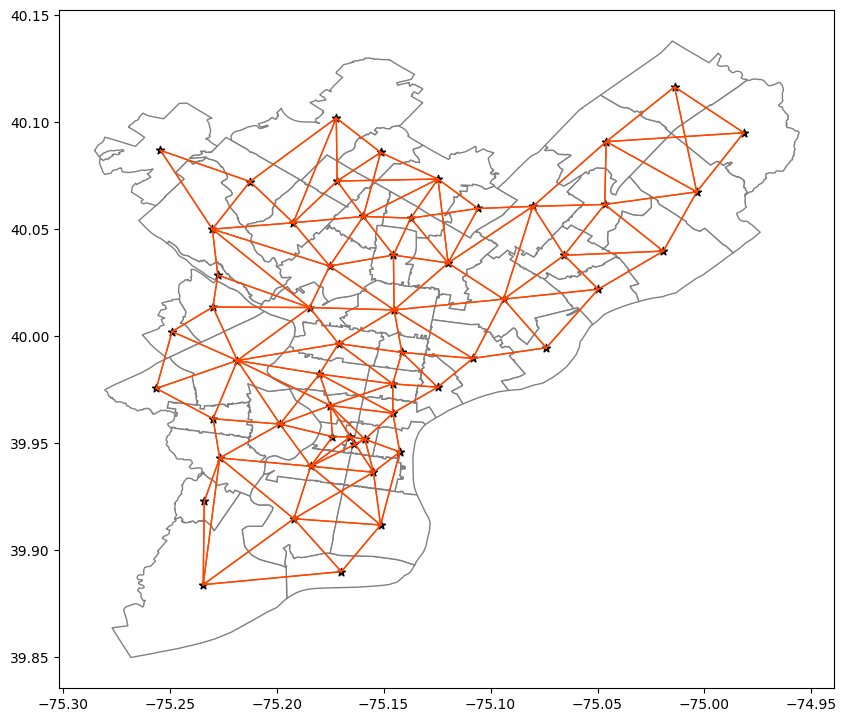

In [5]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

## Retardos espaciales

Ahora se construira el retardo espacial para cada zona.

In [6]:
# Transformar pesos por filas
wq.transform = "R"

In [7]:
# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

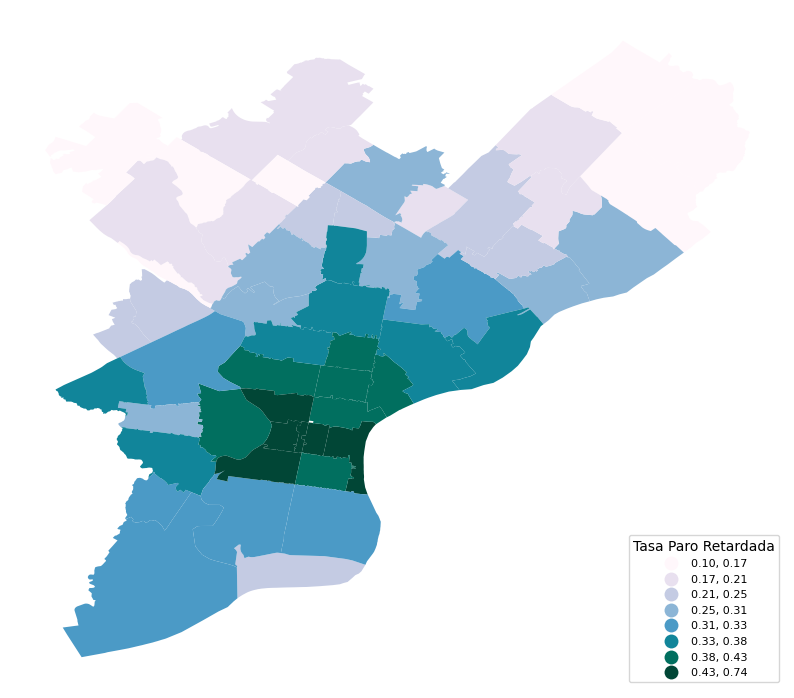

In [8]:
# representación de la tasa de paro retardada
map=aggregate_df_train.plot(column='risk_score_lag', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Tasa Paro Retardada'} 
)
map.set_axis_off() 

## Autocorrelación Espacial

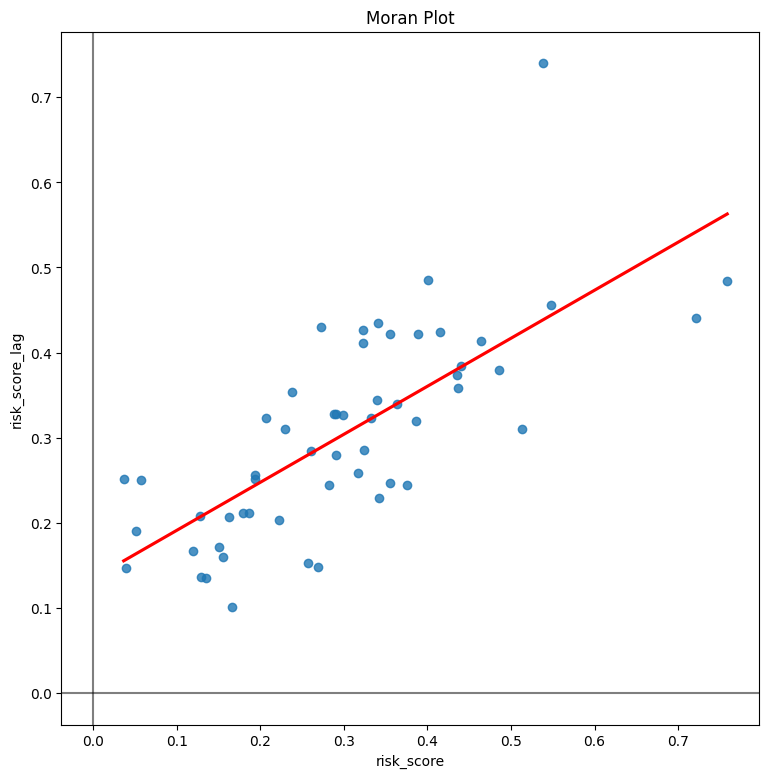

In [9]:
# AutoCorrelación Espacial
f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot")
plt.show()

In [10]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.564
p-valor: 0.001


## Correlación Espacial Local

In [11]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq)

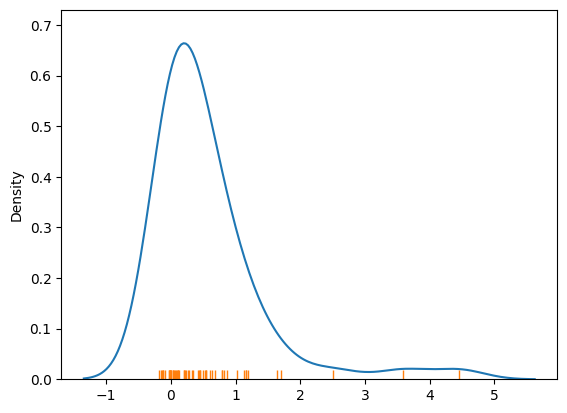

In [12]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

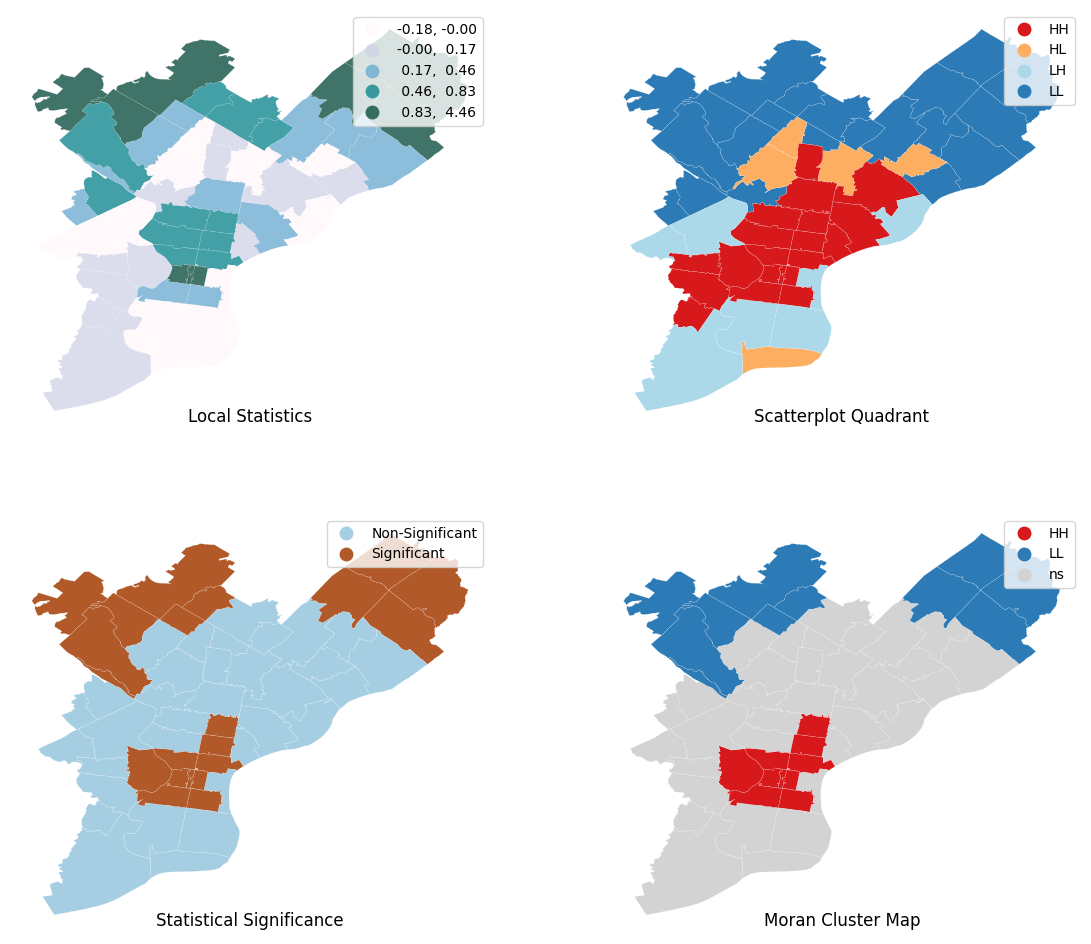

In [13]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
aggregate_df_train.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="PuBuGn",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [14]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].head(20)

0     Non-Significant
1     Non-Significant
2     Non-Significant
3                  LL
4     Non-Significant
5                  LL
6                  HH
7                  HH
8                  HH
9     Non-Significant
10                 HH
11                 HH
12    Non-Significant
13    Non-Significant
14                 LL
15                 LL
16                 LL
17                 LL
18    Non-Significant
19    Non-Significant
Name: labels, dtype: object

In [15]:
aggregate_df_train['labels'].value_counts()

labels
Non-Significant    33
LL                 11
HH                 11
Name: count, dtype: int64

In [16]:
# Procedemos a añadir la el risk score rezagado a la base original
aggregate_df_train_filter = aggregate_df_train[['ZCTA', 'risk_score_lag', 'sig', 'labels']]

In [17]:
# Procedemos a hacer merge con DF original
df_train_with_lag = df_train.merge(aggregate_df_train_filter, how= 'left', on='ZCTA')
df_train_with_lag.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry,risk_score_lag,sig,labels
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,22.5,32.9,8.7,0.5465,0.386350,Moderate,"POLYGON ((-75.21367 39.96003, -75.21204 39.959...",0.410693,1,HH
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,20.5,45.4,5.6,0.4680,0.403469,Moderate,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518...",0.228665,0,Non-Significant
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,26.8,29.9,3.6,0.5170,0.529389,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008...",0.373062,0,Non-Significant


In [18]:
# Lista de variables a borrar para mantener limpio el ambiente
variables_a_borrar = ['fig', 'var_name', 'axes', 'ax', 'axs', 'df_train', 'f', 'i', 'labels', 'lisa', 'map', 'moran', 'sig', 'spots', 'spots_labels', 'wq', 'var_name', 'variables_a_borrar']
for var_name in variables_a_borrar:
   if var_name in globals():
       del globals()[var_name]

# Modelo XGBoost

In [19]:
# Carga de los datos 
train = gpd.GeoDataFrame(df_train_with_lag, geometry='geometry')
val = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Validation/df_val_with_score_ZCTACoordinates.shp'))
test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))

In [20]:
# Se hace el merge con la variable risk_score_lag
val = val.merge(aggregate_df_train_filter, how= 'left', on='ZCTA')
test = test.merge(aggregate_df_train_filter, how='left', on='ZCTA')

In [21]:
# Se extraen de manera individual las coordenadas
train.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry,risk_score_lag,sig,labels
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,22.5,32.9,8.7,0.5465,0.386350,Moderate,"POLYGON ((-75.21367 39.96003, -75.21204 39.959...",0.410693,1,HH
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,20.5,45.4,5.6,0.4680,0.403469,Moderate,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518...",0.228665,0,Non-Significant
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,26.8,29.9,3.6,0.5170,0.529389,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008...",0.373062,0,Non-Significant


## Selección de variables

### Variables Numéricas

num_features = [
    'area_mile2', 'population', 'density_mile2', 'white_race',
    'black_race', 'asian_race', 'latino_race', 
    'median_income', 'mean_income', 'total_households',
    'household_25k_or_less', 'household_25k_to_50k',
    'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
    'risk_score_lag'
]

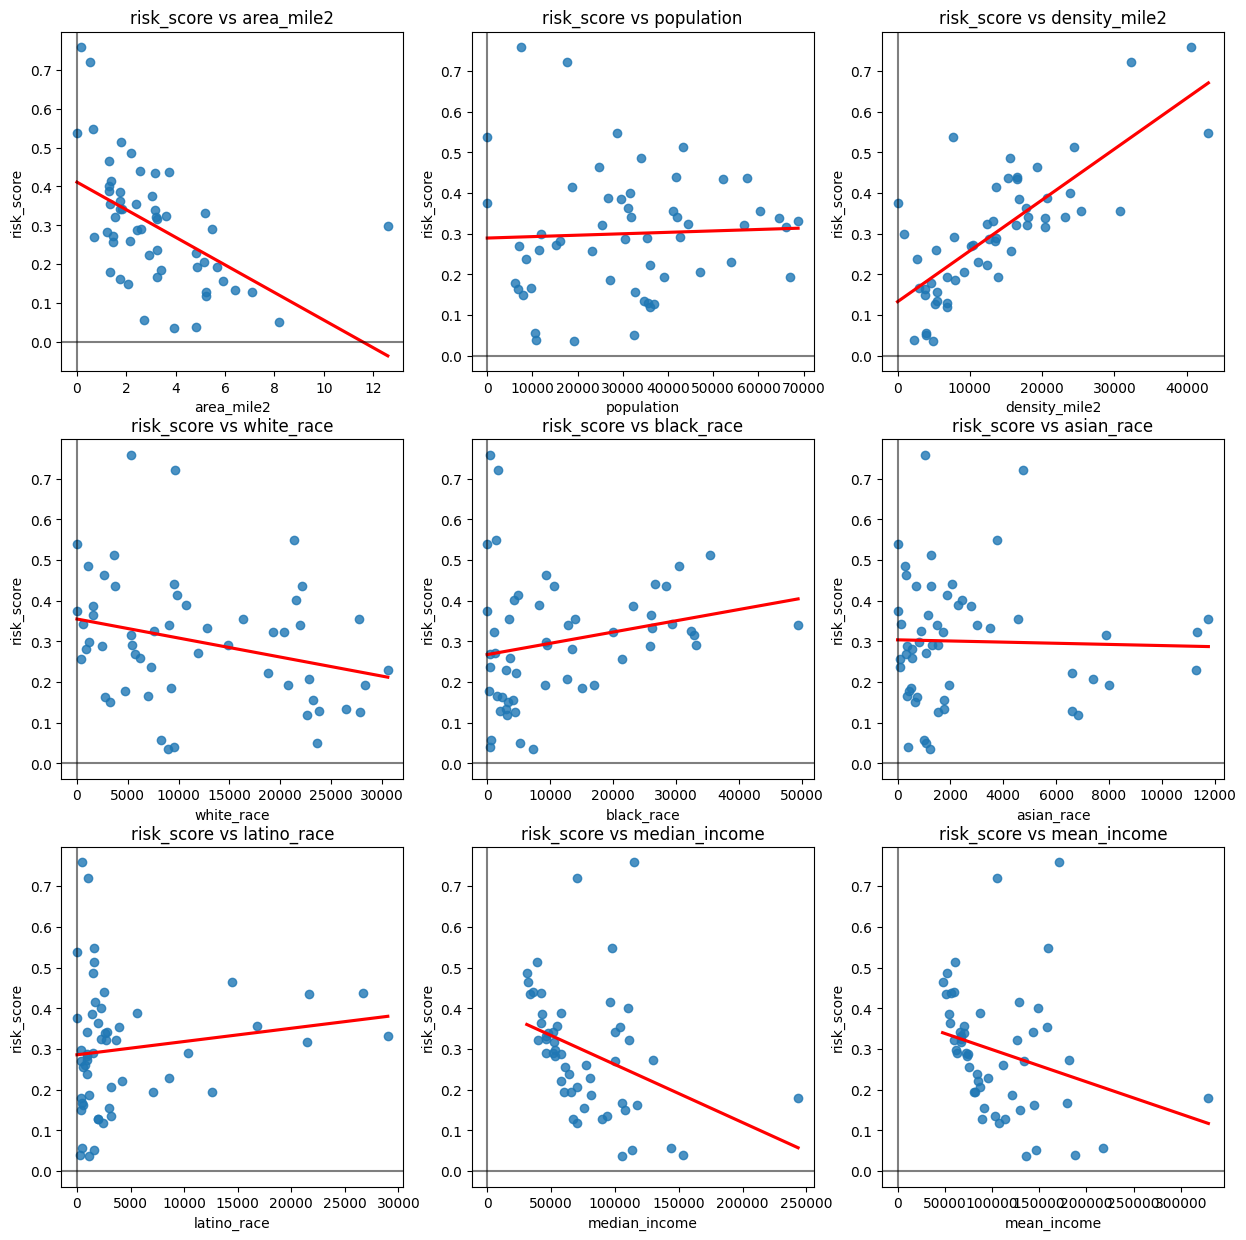

In [22]:
# Variables explicativas
x_vars = [
    'area_mile2', 'population', 'density_mile2', 
    'white_race', 'black_race', 'asian_race', 
    'latino_race','median_income', 'mean_income'
]

# Crear la figura con subplots en forma de 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()  # aplanar para indexar fácilmente

# Loop para crear cada gráfico
for i, x_var in enumerate(x_vars):
    sns.regplot(
        x=x_var,
        y="risk_score",
        data=aggregate_df_train,
        ci=None,
        line_kws={"color": "r"},
        ax=axes[i]
    )
    axes[i].axhline(0, c="k", alpha=0.5)
    axes[i].axvline(0, c="k", alpha=0.5)
    axes[i].set_title(f"risk_score vs {x_var}")

Esto nos graficos de dispersión nos dan una idea respecto a cuales variables presentan una relación, ya sea positiva o negativa, o en todo caso, que no presente relación del todo. Algunos insights son:

- Relación negativa entre área de la zona ZCTA y el risk score.
- La población no parece tener un relación clara con el risk score; por otra parte, la densidad poblacional sí denota una relación positiva clara. Esto podría estar ligado a la misma área de la zona, ya que vimos que entre más pequeña el área, se presenta un score más alto pero a la vez, esas mismas zonas con menos áreas suelen presentar densidades poblacionales mayores.
- Con el tema de las población por raza se distinguen varios hallazgos:
    - Entre mayor es la cantidad sea persona blancas, se tiende a tener score más bajos.
    - De forma inversa pasa con los latinos y las personas negras
    - Con la población asiática, realmente no se distingue un patrón claro por lo que se descartarán.
    - A modo de conclusión, se creará una variable que unifique la población negra con la latina y la población blanca de mantendrá por aparte.
- Tanto con la media y mediana del ingreso muestran una asociación negativa con el risk score por lo que para efectos del cálculo. Acá cabe resaltar que curiosamente las áreas que presentan el mayor ingreso, son también las que presentan el mayor índice de riesgo. 



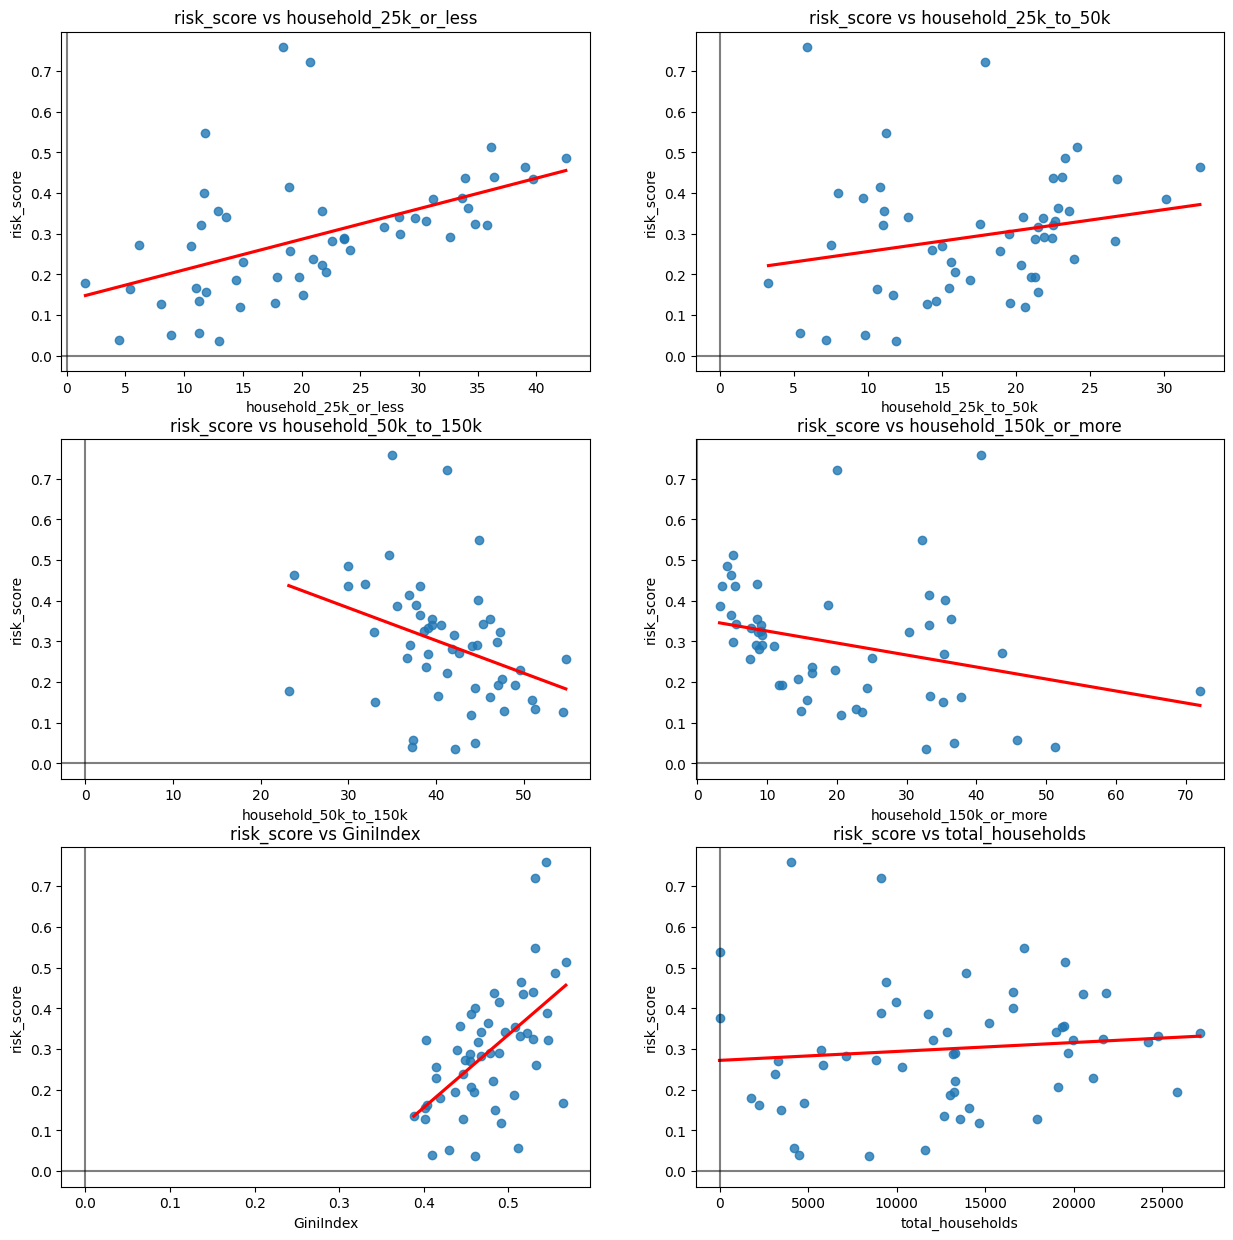

In [30]:
# Variables que irán en X
x_vars = [
    'household_25k_or_less', 'household_25k_to_50k', 'household_50k_to_150k', 
    'household_150k_or_more', 'GiniIndex', 'total_households'
]

# Crear la figura con subplots en forma de 3x3
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()  # aplanar para indexar fácilmente

# Loop para crear cada gráfico
for i, x_var in enumerate(x_vars):
    sns.regplot(
        x=x_var,
        y="risk_score",
        data=aggregate_df_train,
        ci=None,
        line_kws={"color": "r"},
        ax=axes[i]
    )
    axes[i].axhline(0, c="k", alpha=0.5)
    axes[i].axvline(0, c="k", alpha=0.5)
    axes[i].set_title(f"risk_score vs {x_var}")

Por otro lado, las siguiente variables también nos dan insights muy interesantes:

- Los primeros cuatro gráficos son relacionados al porcentaje (%) de households que presentan los diferentes rango de ingresos y notamos un patrón muy claro. 
    - Para aquellos hogares que presentan un ingreso anual menor a los 25k dólares, hay una clara asociación positiva, es decir, entre más crece el porcentaje de hogares con este ingreso anual, el índice tiende a crecer.
    - Esta dinámica se mantiene para el rango de los 25k a los 50k dólares, pero en menor medida.
    - Para cuando llegamos al tercer rango, la asociación se invierte, es decir, entre más crece el % de hogares en este rango de ingreso, el score se reduce.
    - De manera análoga sucede para el último rango de ingresos.
- Por otro lado, el índice de Gini muestra una muy clara relación positiva lo cual hace mucho sentido social, entre mayor sea la disparidad de ingresos en una zona, mayor peligro presentará.
- Por último, tenemos la relación entre el risk score y la cantidad de hogares que su gráfico de dispersión no muestra una asociación entre ambas.

Acabamos de analizar todas aquellas variables cuya información estaba por zona postal y se procederá a eliminar aquellas que para efectos de este primer acercamiento exploratorio no han mostrado tener una relación directa con la variable objetivo. Estas son:

- Área, población y densidad: a pesar de que el área y la densidad sí presentaron una relación clara, la misma está explicada por el hecho de que fueron utilizadas para la construcción del índice por lo que no tiene sentido y estariamos incurriendo en data leakage.
- La población asiática se descartara, y la población negra y latina se unificarán en una sola variable. Además, consideraremos estas variable poblacionales como el % de dicha raza que habita en esa zona y no en términos absolutos. 
- La mediana y media del ingreso mostraron una relación muy consistente entre ambos, por lo que para efectos del modelado solo se tomará la mediana y se descarta el promedio.
- La cantidad de hogares (households) también se procederá a descartarla.

In [27]:
train['white_race'] = train['white_race']/train['population']
train['others_races'] = (train['black_race'] + train['latino_race'])/train['population']

In [36]:
TARGET = 'risk_score'
# Se eliminan variables que a priori no se utilizaran (Se eliminan adicionalmente la geometría, el risk score y el risk label)
drop_cols = ['area_mile2', 'population', 'density_mile2', 'black_race', 'asian_race', 'latino_race', 'mean_income', 'total_households']
X_train_model = train.drop(columns=drop_cols, errors='ignore')
X_valid_model = val.drop(columns=drop_cols, errors='ignore')
X_test_model = test.drop(columns=drop_cols, errors='ignore')

y_train = train[TARGET]
y_valid = val[TARGET]
y_test = test[TARGET]


Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA', 'white_race', 'median_income',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry', 'risk_score_lag', 'sig',
       'labels'],
      dtype='object')

In [94]:
X_valid_model.columns

Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA', 'white_race', 'median_income',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry', 'risk_score_lag', 'sig',
       'labels'],
      dtype='object')

Ahora procederemos a analizar la relación que existe con aquellas variables que no están agrupadas por área. Dado que la mayoría de estas variables son categorías, se utilizará el risk_label en vez del risk_score. Al final tanto el risk score como el risk label son diferentes representaciones de un mismo concepto y al hacer la comparación entre dos variables categóricas nos podemos apoyar de herramientas como el test chi cuadrado.

<Axes: xlabel='time_of_day', ylabel='risk_score'>

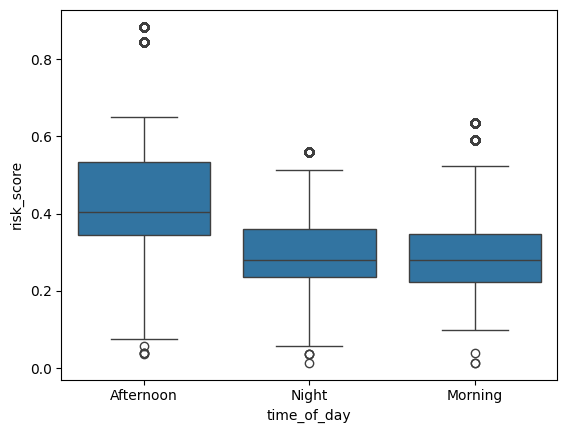

In [38]:
sns.boxplot(x="time_of_day", y="risk_score", data=train)

In [85]:
ctabla=pd.crosstab(train['day_of_week'],train['risk_level'],margins=True).round(3)
ctabla

risk_level,High,Low,Moderate,All
day_of_week,,,,
Friday,4667,5003,15134,24804
Monday,5133,5458,16012,26603
Saturday,3782,4353,13273,21408
Sunday,3728,4412,12615,20755
Thursday,4979,5012,15312,25303
Tuesday,5263,5122,16307,26692
Wednesday,5134,5188,15850,26172
All,32686,34548,104503,171737


In [86]:
# test Chi-cuadrado de independencia (Ho: ausencia de asociación) 
c, p, dof, expected = chi2_contingency(ctabla) 
# Print the p-value
print(p)

1.9988337116137552e-10


In [87]:
residuals = (ctabla - expected) / np.sqrt(expected)
print(residuals)

risk_level       High       Low  Moderate  All
day_of_week                                   
Friday      -0.783656  0.187254  0.330604  0.0
Monday       0.980374  1.453431 -1.383971  0.0
Saturday    -4.582309  0.706960  2.156236  0.0
Sunday      -3.535586  3.664052 -0.129405  0.0
Thursday     2.351482 -1.095454 -0.685242  0.0
Tuesday      2.564994 -3.378640  0.508117  0.0
Wednesday    2.164854 -1.060784 -0.600803  0.0
All          0.000000  0.000000  0.000000  0.0


In [88]:
n = ctabla.sum().sum()
cramers_v = np.sqrt(c / (n * (min(ctabla.shape)-1)))
print("Cramér's V:", cramers_v)

Cramér's V: 0.006588617645625622


In [97]:
cat_vars = ['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA']
results_df = chi2_cramersv(train, target="risk_level", cat_vars=cat_vars)
print(results_df)

NameError: name 'chi2_cramersv' is not defined

In [92]:
# Tabla de contingencia con márgenes
ctabla = pd.crosstab(train['time_of_day'], train['risk_level'], margins=True).round(3)
# Elimina la fila y columna "All" para el análisis
ctabla_sin_margenes = ctabla.iloc[:-1, :-1]
# Test chi²
chi2, p, dof, expected = chi2_contingency(ctabla_sin_margenes)
# Cálculo de V de Cramér
n = ctabla_sin_margenes.to_numpy().sum()
phi2 = chi2 / n
r, k = ctabla_sin_margenes.shape
cramer_v = np.sqrt(phi2 / min(k - 1, r - 1))
print('p-value Chi2:', p, '\nV de Cramér:', cramer_v)

p-value Chi2: 0.0 
V de Cramér: 0.29972117408343124


In [54]:
train['is_holiday'].value_counts(normalize=True,dropna=False).sort_values(ascending=False)

is_holiday
False    0.970036
True     0.029964
Name: proportion, dtype: float64

## Modelado

In [74]:
# Se dividen las variables entre numericas o categoricas
num_features = [
    'area_mile2', 'population', 'density_mile2', 'white_race',
    'black_race', 'asian_race', 'latino_race', 'density_mile2',
    'median_income', 'mean_income', 'total_households',
    'household_25k_or_less', 'household_25k_to_50k',
    'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
    'risk_score_lag'
]

cat_features = [
    'hour', 'psa', 'time_of_day', 'ZCTA',
    'day_of_week', 'season',
    'crimeType', 'is_holiday', 'sig'
]

# Asegurar que todas las columnas categóricas sean de tipo category
for col in cat_features:
    if col in X_train_model.columns:
        X_train_model[col] = X_train_model[col].astype(str)
        X_valid_model[col] = X_valid_model[col].astype(str)

In [75]:
X_train_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   psa                     171737 non-null  object 
 1   hour                    171737 non-null  object 
 2   time_of_day             171737 non-null  object 
 3   day_of_week             171737 non-null  object 
 4   season                  171737 non-null  object 
 5   is_holiday              171737 non-null  object 
 6   crimeType               171737 non-null  object 
 7   ZCTA                    171737 non-null  object 
 8   area_mile2              171737 non-null  float64
 9   population              171737 non-null  int64  
 10  white_race              171737 non-null  int64  
 11  black_race              171737 non-null  int64  
 12  asian_race              171737 non-null  int64  
 13  latino_race             171737 non-null  int64  
 14  density_mile2       

In [77]:
# Preprocesado de variables 
## Las numericas se estandarizan y las categorial se convierten en dummies
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

# Transforma los datos primero
X_train_processed = preprocessor.fit_transform(X_train_model)
X_valid_processed = preprocessor.transform(X_valid_model)

# le = LabelEncoder()
y_train_enc = y_train.astype(float)  # Low=0, Moderate=1, High=2
y_valid_enc = y_valid.astype(float)  # le.transform(y_valid)

In [78]:
print(y_train)
print(y_train_enc)

0         0.386350
1         0.403469
2         0.529389
3         0.342670
4         0.359987
            ...   
171732    0.327732
171733    0.401305
171734    0.401305
171735    0.341173
171736    0.165011
Name: risk_score, Length: 171737, dtype: float64
0         0.386350
1         0.403469
2         0.529389
3         0.342670
4         0.359987
            ...   
171732    0.327732
171733    0.401305
171734    0.401305
171735    0.341173
171736    0.165011
Name: risk_score, Length: 171737, dtype: float64


In [79]:
# ----------------------------
# Model
# ----------------------------
""" xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    objective='multi:softprob',     # clasificación múltiple
    num_class=3,
    eval_metric='mlogloss'
) """

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',   # <<--- regresión
    eval_metric='rmse'              # <<--- métrica típica de regresión
)

In [80]:
# Se ajustan los datos al modelo ya creado
xgb.fit(
    X_train_processed, 
    y_train_enc, 
    eval_set=[(X_valid_processed, y_valid_enc)], verbose=True
)

[0]	validation_0-rmse:0.19555
[1]	validation_0-rmse:0.19385
[2]	validation_0-rmse:0.19245
[3]	validation_0-rmse:0.19131
[4]	validation_0-rmse:0.19102
[5]	validation_0-rmse:0.19034
[6]	validation_0-rmse:0.18984
[7]	validation_0-rmse:0.18948
[8]	validation_0-rmse:0.18927
[9]	validation_0-rmse:0.18919
[10]	validation_0-rmse:0.18920
[11]	validation_0-rmse:0.18931
[12]	validation_0-rmse:0.18950
[13]	validation_0-rmse:0.18975
[14]	validation_0-rmse:0.19006
[15]	validation_0-rmse:0.19042
[16]	validation_0-rmse:0.19082
[17]	validation_0-rmse:0.19126
[18]	validation_0-rmse:0.19170
[19]	validation_0-rmse:0.19215
[20]	validation_0-rmse:0.19263
[21]	validation_0-rmse:0.19311
[22]	validation_0-rmse:0.19393
[23]	validation_0-rmse:0.19440
[24]	validation_0-rmse:0.19489
[25]	validation_0-rmse:0.19537
[26]	validation_0-rmse:0.19586
[27]	validation_0-rmse:0.19631
[28]	validation_0-rmse:0.19677
[29]	validation_0-rmse:0.19723
[30]	validation_0-rmse:0.19768
[31]	validation_0-rmse:0.19811
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

## Métricas para Regresión

In [81]:
y_pred = np.clip(xgb.predict(X_valid_processed), 0.0, 1.0)

# Example evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("RMSE:", mean_squared_error(y_valid, y_pred, squared=False))
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("R2:", r2_score(y_valid, y_pred))

RMSE: 0.20851988553417705
MAE: 0.18670886399299624
R2: -9.212624357953269


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<Axes: >

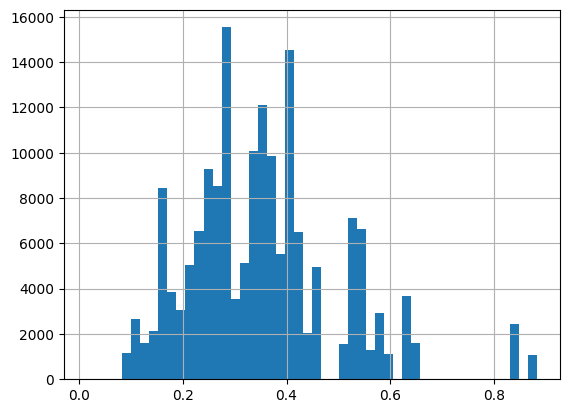

In [82]:
y_train.hist(bins=50)

## Métricas para Clasificación

In [123]:
y_pred = xgb.predict(X_valid_processed)
y_pred_labels = np.argmax(y_pred, axis=1)

In [124]:
y_pred = xgb.predict(X_valid_processed)
accuracy_score(y_valid_enc, y_pred_labels)

0.2158640226628895

In [125]:
cm = confusion_matrix(y_valid_enc, y_pred_labels)

In [126]:
cm

array([[  251,     0,     0],
       [ 3784,  6776, 20133],
       [ 2379,     0,   212]], dtype=int64)

In [127]:
print(classification_report(y_valid_enc, y_pred_labels))

              precision    recall  f1-score   support

           0       0.04      1.00      0.08       251
           1       1.00      0.22      0.36     30693
           2       0.01      0.08      0.02      2591

    accuracy                           0.22     33535
   macro avg       0.35      0.43      0.15     33535
weighted avg       0.92      0.22      0.33     33535

